# Baseline DenseNet-121 — CEDAR Split Evaluation

Standard DenseNet-121 binary classifier (Genuine / Forged) trained with cross-entropy loss and evaluated across three train-val-test split ratios.

| | |
|---|---|
| **Dataset** | CEDAR |
| **Splits** | 60:20:20 · 65:18:18 · 70:15:15 |
| **Epochs** | 100 (matches proposed model's 30 + 70 combined budget) |

**Prerequisite:** run `scripts/prepare_split_ratios.py` to generate split JSONs.

## Step 1 — Imports & Reproducibility

In [1]:
import os, sys, json, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image

# ── Repo root ─────────────────────────────────────────────────────────────────
REPO_ROOT = os.path.abspath(os.path.join(os.path.abspath(os.getcwd()), '..'))
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

# ── Custom modules ────────────────────────────────────────────────────────────
from models.feature_extractor import DenseNetFeatureExtractor
from utils.model_evaluation   import (compute_metrics, _plot_det_curve,
                                       _plot_far_frr, _plot_confusion_matrix,
                                       _plot_score_distribution, _plot_roc_curve)
from dataloader.tDCBAM_trainloader import get_transforms

# ── Reproducibility ───────────────────────────────────────────────────────────
def seed_everything(seed=42):
    """Seed all random sources for full reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f" > [Seed] {seed}")

seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" > [Device] {DEVICE}" +
      (f"  ({torch.cuda.get_device_name()})" if torch.cuda.is_available() else ""))


/home/lawrence/workspace/thesis/thesis/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


 > [Seed] 42
 > [Device] cuda  (NVIDIA GeForce RTX 5080)


## Step 2 — Configuration

In [2]:
# ── Identity ──────────────────────────────────────────────────────────────────
NOTEBOOK_NAME = 'baseline_cedar'
DATASET       = 'cedar'
DATASET_NAME  = 'CEDAR'

# ── Paths ─────────────────────────────────────────────────────────────────────
SPLIT_DIR      = os.path.join(REPO_ROOT, 'data',        'ratio_splits')
CHECKPOINT_DIR = os.path.join(REPO_ROOT, 'checkpoints', 'baseline_splits')
EVAL_DIR       = os.path.join(REPO_ROOT, 'model_evals',  NOTEBOOK_NAME)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR,       exist_ok=True)

# ── Split ratios ──────────────────────────────────────────────────────────────
SPLIT_RATIOS = ['70_15_15']

# ── Data ──────────────────────────────────────────────────────────────────────
IMG_SIZE    = 224
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE)
NUM_WORKERS = 4

# ── Training ──────────────────────────────────────────────────────────────────
# 100 total epochs matches the proposed model's combined budget (30 + 70).
# AdamW betas=(0.9, 0.999) and ReduceLROnPlateau(factor=0.5, patience=5) on
# val EER mirror the proposed model's meta-training scheduler for a fair
# apples-to-apples comparison between the two architectures.
EPOCHS       = 100
BATCH_SIZE   = 30       
LR           = 1e-3
WEIGHT_DECAY = 1e-4   
MOMENTUM = 0.99

print(f" > [Config] {DATASET_NAME} | Splits: {SPLIT_RATIOS}")
print(f" > [Config] Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR} | WD: {WEIGHT_DECAY}")
print(f" > [Config] Checkpoints: {CHECKPOINT_DIR}")


 > [Config] CEDAR | Splits: ['70_15_15']
 > [Config] Epochs: 100 | Batch: 30 | LR: 0.001 | WD: 0.0001
 > [Config] Checkpoints: /home/lawrence/workspace/thesis/thesis/checkpoints/baseline_splits


## Step 3 — Transforms

> This cell is **verbatim identical** in both the baseline and the proposed notebook. Any change here must be mirrored in the other notebook.

In [3]:
# ── Transform factory ─────────────────────────────────────────────────────────
# get_transforms() returns a single torchvision.transforms.Compose — NOT a tuple.
#   mode='train'  →  preprocess_image(augment=True):  geometric augmentation ON
#   mode='val'    →  preprocess_image(augment=False): preprocessing only
#
# Both notebooks share this exact cell so that the preprocessing pipeline is
# byte-for-byte identical across the baseline and the proposed model.
train_transform = get_transforms(mode='train', input_shape=INPUT_SHAPE)
val_transform   = get_transforms(mode='val',   input_shape=INPUT_SHAPE)

print(" > [Transforms] train_transform: augmentation ON  (geometric)")
print(" > [Transforms] val_transform  : augmentation OFF (preprocessing only)")


 > [Transforms] train_transform: augmentation ON  (geometric)
 > [Transforms] val_transform  : augmentation OFF (preprocessing only)


## Step 4 — Dataset

In [4]:
class SplitDataset(Dataset):
    """
    Flat binary classification dataset built from a split-JSON user dict.

    Labels:  0 = Genuine,  1 = Forged
    Handles both key styles: 'genuine'/'gen'  and  'forged'/'forgeries'/'forg'.
    The transform is passed in at construction time so that train vs val/test
    augmentation is controlled externally via get_transforms(mode=...).
    """
    def __init__(self, user_dict, transform=None):
        self.transform = transform
        self.samples   = []

        for uid, data in user_dict.items():
            gen_key  = next((k for k in data if k.lower() in ('genuine', 'gen')),             None)
            forg_key = next((k for k in data if k.lower() in ('forged', 'forgeries', 'forg')), None)
            if gen_key:
                self.samples += [(p, 0) for p in data[gen_key]]    # 0 = Genuine
            if forg_key:
                self.samples += [(p, 1) for p in data[forg_key]]   # 1 = Forged

        n_gen  = sum(1 for _, l in self.samples if l == 0)
        n_forg = sum(1 for _, l in self.samples if l == 1)
        print(f"   SplitDataset: {len(self.samples)} samples "
              f"({n_gen} genuine + {n_forg} forged) | {len(user_dict)} users")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
            if self.transform:
                img = self.transform(img)
        except Exception as e:
            print(f"   WARNING: could not load {path}: {e}")
            img = torch.zeros(3, IMG_SIZE, IMG_SIZE)
        return img, label

print(" > [Dataset] SplitDataset defined")


 > [Dataset] SplitDataset defined


## Step 5 — Data Preview

Visualise a sample of preprocessed + augmented training images **before** training begins. Run this cell to verify the full preprocessing pipeline (binarisation → dilation → crop → pad → normalise) is working correctly.

 > [Viz] Preview using split '70_15_15'
   SplitDataset: 1824 samples (912 genuine + 912 forged) | 38 users


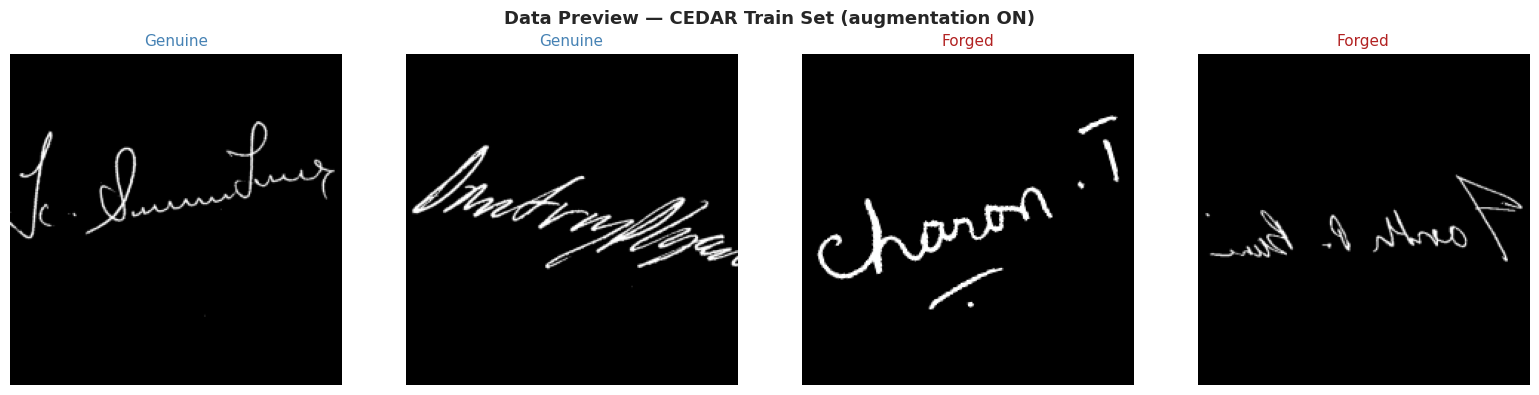

 > [Viz] Displayed 4 samples (2 genuine, 2 forged)


In [5]:
def _unnorm(t):
    """Undo ImageNet normalisation for display. Returns H×W×C numpy in [0, 1]."""
    img  = t.cpu().numpy().transpose(1, 2, 0)          # C,H,W → H,W,C
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    return np.clip(std * img + mean, 0, 1)


# ── Preview: load first available split and sample from its train set ─────────
# Runs independently of the training loop — purely for pipeline verification.
# Shows up to 2 genuine and 2 forged samples so both classes are visible.
_prev_data = None
for _r in SPLIT_RATIOS:
    _f = os.path.join(SPLIT_DIR, f"{DATASET}_split_{_r}.json")
    if os.path.exists(_f):
        with open(_f) as _fh:
            _prev_data = json.load(_fh)
        print(f" > [Viz] Preview using split '{_r}'")
        break

if _prev_data is None:
    print(" > [Viz] No split file found — run prepare_split_ratios.py first")
else:
    _ds      = SplitDataset(_prev_data['train'], transform=train_transform)
    _loader  = DataLoader(_ds, batch_size=8, shuffle=True, num_workers=0)
    _imgs, _labels = next(iter(_loader))

    # Collect up to 2 genuine (label=0) and 2 forged (label=1) indices
    _gen_idx  = [i for i, l in enumerate(_labels.tolist()) if l == 0][:2]
    _forg_idx = [i for i, l in enumerate(_labels.tolist()) if l == 1][:2]
    _show     = _gen_idx + _forg_idx

    fig, axes = plt.subplots(1, len(_show), figsize=(4 * len(_show), 4))
    fig.suptitle(f"Data Preview — {DATASET_NAME} Train Set (augmentation ON)",
                 fontsize=13, fontweight='bold')

    for ax, i in zip(axes, _show):
        lbl = "Genuine" if _labels[i].item() == 0 else "Forged"
        ax.imshow(_unnorm(_imgs[i]))
        ax.set_title(lbl, fontsize=11,
                     color='steelblue' if lbl == 'Genuine' else 'firebrick')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    print(f" > [Viz] Displayed {len(_show)} samples ({len(_gen_idx)} genuine, {len(_forg_idx)} forged)")


## Step 6 — Training Utilities

In [6]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """One training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(out, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate_model(model, loader, device, output_dir=None, silent=False):
    """
    Evaluate baseline model. Collects P(Forged) = softmax(logits)[:, 1] as
    the anomaly score and passes it to compute_metrics() with label 1 = Forged.
    Score and label polarity are consistent — EER / AUC are correct as-is.
    """
    model.eval()
    all_labels, all_scores = [], []
    bar = tqdm(loader, desc="Eval", leave=False) if not silent else loader

    with torch.no_grad():
        for imgs, labels in bar:
            imgs   = imgs.to(device)
            probs  = torch.softmax(model(imgs), dim=1)[:, 1]  # P(Forged)
            all_scores.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    metrics = compute_metrics(all_labels, all_scores)

    if output_dir and not silent:
        print(f"\n{'='*10} FINAL TEST RESULTS {'='*10}")
        for k, fmt in [('eer',':.2%'),('auc',':.4f'),('threshold',':.4f'),
                       ('accuracy',':.2%'),('precision',':.2%'),
                       ('recall',':.2%'),('f1',':.2%')]:
            print(f"  {k.upper():<13}: {metrics.get(k, 0):{fmt[1:]}}")
        print("=" * 38)
        _plot_roc_curve(metrics, output_dir)
        _plot_score_distribution(metrics, output_dir)
        _plot_confusion_matrix(metrics, output_dir)
        _plot_det_curve(metrics, output_dir)
        _plot_far_frr(metrics, output_dir)

    return metrics


def train_full_pipeline(model, train_loader, val_loader, device,
                        epochs, lr, weight_decay, checkpoint_path):
    """
    Full training pipeline: AdamW + ReduceLROnPlateau, best model by val EER.

    Optimizer / scheduler settings mirror the proposed model's meta-training
    Phase 1 for a fair comparison:
        AdamW(betas=(0.9, 0.999), weight_decay=weight_decay)
        ReduceLROnPlateau(mode='min', factor=0.5, patience=5) on val EER.

    Checkpoint saved whenever val EER improves (tie-broken by accuracy).
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr,
                            weight_decay=weight_decay, betas=(MOMENTUM, MOMENTUM))
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=5)
    best_eer, best_acc, best_metrics = 1.0, 0.0, {}

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_m           = evaluate_model(model, val_loader, device, silent=True)
        val_eer, val_acc = val_m['eer'], val_m['accuracy']

        print(f"   Epoch {epoch+1:03d}/{epochs} | "
              f"Loss: {tr_loss:.4f} | Acc: {tr_acc:.2%} | "
              f"Val EER: {val_eer:.2%} | Val Acc: {val_acc:.2%}")
        scheduler.step(val_eer)

        if val_eer < best_eer or (val_eer == best_eer and val_acc > best_acc):
            best_eer, best_acc, best_metrics = val_eer, val_acc, val_m
            torch.save({'model_state_dict': model.state_dict(),
                        'metrics': val_m}, checkpoint_path)
            print(f"   >>> Checkpoint saved  (Val EER: {val_eer:.2%})")

    return best_metrics

print(" > [Utils] train_one_epoch, evaluate_model, train_full_pipeline defined")


 > [Utils] train_one_epoch, evaluate_model, train_full_pipeline defined


## Step 7 — Run All Splits

In [7]:
all_results = {}

for ratio in SPLIT_RATIOS:
    split_file = os.path.join(SPLIT_DIR, f"{DATASET}_split_{ratio}.json")
    tr_p, va_p, te_p  = ratio.split('_')
    split_label       = f"{tr_p}:{va_p}:{te_p}"
    split_eval_dir    = os.path.join(EVAL_DIR, f"{NOTEBOOK_NAME}_{tr_p}-{va_p}-{te_p}")
    os.makedirs(split_eval_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"  {DATASET_NAME}  —  {split_label}  Split")
    print(f"{'='*60}")

    if not os.path.exists(split_file):
        print(f"  SKIPPED: split file not found ({split_file})"); continue

    with open(split_file) as f:
        split_data = json.load(f)
    train_dict, val_dict, test_dict = (split_data['train'],
                                       split_data['val'],
                                       split_data['test'])
    print(f"  Writers — Train: {len(train_dict)} | Val: {len(val_dict)} | Test: {len(test_dict)}")

    # ── Datasets ───────────────────────────────────────────────────────────
    # train uses augmentation; val / test use preprocessing only.
    train_ds = SplitDataset(train_dict, transform=train_transform)
    val_ds   = SplitDataset(val_dict,   transform=val_transform)
    test_ds  = SplitDataset(test_dict,  transform=val_transform)

    if not (len(train_ds) and len(val_ds) and len(test_ds)):
        print("  SKIPPED: empty dataset partition"); continue

    # drop_last=True on train prevents incomplete batches during the forward pass.
    # drop_last=False on val / test ensures every sample is evaluated.
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

    # ── Train ──────────────────────────────────────────────────────────────
    seed_everything(42)
    model = DenseNetFeatureExtractor(backbone_name='densenet121', output_dim=2,
                                     pretrained=True, baseline=True).to(DEVICE)
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"best_{DATASET}_{ratio}.pth")
    train_full_pipeline(model, train_loader, val_loader, DEVICE,
                        EPOCHS, LR, WEIGHT_DECAY, ckpt_path)

    # ── Reload best checkpoint → evaluate on held-out test set ────────────
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt.get('model_state_dict', ckpt))

    test_m = evaluate_model(model, test_loader, DEVICE,
                            output_dir=split_eval_dir, silent=False)

    all_results[f"{DATASET_NAME} ({split_label})"] = {
        'dataset':     DATASET_NAME,     'split':       split_label,
        'train_users': len(train_dict),  'val_users':   len(val_dict),
        'test_users':  len(test_dict),
        'eer':       float(test_m['eer']),
        'accuracy':  float(test_m['accuracy']),
        'auc':       float(test_m['auc']),
        'precision': float(test_m.get('precision', 0)),
        'recall':    float(test_m.get('recall',    0)),
        'f1':        float(test_m.get('f1',        0)),
    }
    print(f"  RESULT [{split_label}]: EER={test_m['eer']:.2%} | "
          f"Acc={test_m['accuracy']:.2%} | AUC={test_m['auc']:.4f} | "
          f"F1={test_m.get('f1', 0):.4f}")

print(f"\n{'='*60}\nALL EXPERIMENTS COMPLETE\n{'='*60}")



  CEDAR  —  70:15:15  Split
  Writers — Train: 38 | Val: 8 | Test: 9
   SplitDataset: 1824 samples (912 genuine + 912 forged) | 38 users
   SplitDataset: 384 samples (192 genuine + 192 forged) | 8 users
   SplitDataset: 432 samples (216 genuine + 216 forged) | 9 users
 > [Seed] 42


Train:   0%|          | 0/60 [00:00<?, ?it/s]

   Epoch 001/100 | Loss: 0.7248 | Acc: 61.33% | Val EER: 43.75% | Val Acc: 56.25%
   >>> Checkpoint saved  (Val EER: 43.75%)


Train:   0%|          | 0/60 [00:00<?, ?it/s]

   Epoch 002/100 | Loss: 0.5724 | Acc: 72.11% | Val EER: 29.17% | Val Acc: 70.83%
   >>> Checkpoint saved  (Val EER: 29.17%)


...

   Epoch 099/100 | Loss: 0.0798 | Acc: 96.72% | Val EER: 32.29% | Val Acc: 67.71%


Train:   0%|          | 0/60 [00:00<?, ?it/s]

   Epoch 100/100 | Loss: 0.0796 | Acc: 96.94% | Val EER: 31.77% | Val Acc: 68.23%


Eval:   0%|          | 0/15 [00:00<?, ?it/s]


========== FINAL TEST RESULTS ==========
  EER          : 25.93%
  AUC          : 0.7880
  THRESHOLD    : 0.9103
  ACCURACY     : 74.07%
  PRECISION    : 74.07%
  RECALL       : 74.07%
  F1           : 74.07%
 > Saved ROC Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar/baseline_cedar_70-15-15/roc_curve.png
 > Saved Distribution Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar/baseline_cedar_70-15-15/score_distribution.png
 > Saved Confusion Matrix to: /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar/baseline_cedar_70-15-15/confusion_matrix.png
 > Saved DET Curve to: /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar/baseline_cedar_70-15-15/det_curve.png
 > Saved FAR/FRR Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar/baseline_cedar_70-15-15/far_frr.png
  RESULT [70:15:15]: EER=25.93% | Acc=74.07% | AUC=0.7880 | F1=0.7407

ALL EXPERIMENTS COMPLETE


## Step 8 — Summary Table

In [8]:
W = 80
print(f"\n{'='*W}")
print(f"{'BASELINE DENSENET121  —  ' + DATASET_NAME:^{W}}")
print(f"{'='*W}")
print(f"{'Split':<12} {'Train':>6} {'Val':>6} {'Test':>6}  "
      f"{'EER':>8} {'Accuracy':>9} {'AUC':>8} {'F1':>8}")
print(f"{'-'*W}")
for res in all_results.values():
    print(f"{res['split']:<12} {res['train_users']:>6} {res['val_users']:>6} "
          f"{res['test_users']:>6}  {res['eer']:>8.4f} {res['accuracy']:>9.4f} "
          f"{res['auc']:>8.4f} {res['f1']:>8.4f}")
print(f"{'='*W}")

results_path = os.path.join(CHECKPOINT_DIR, f'baseline_{DATASET}_results.json')
with open(results_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"\n > Results saved → {results_path}")



                         BASELINE DENSENET121  —  CEDAR                         
Split         Train    Val   Test       EER  Accuracy      AUC       F1
--------------------------------------------------------------------------------
70:15:15         38      8      9    0.2593    0.7407   0.7880   0.7407

 > Results saved → /home/lawrence/workspace/thesis/thesis/checkpoints/baseline_splits/baseline_cedar_results.json


## Step 9 — Results Chart

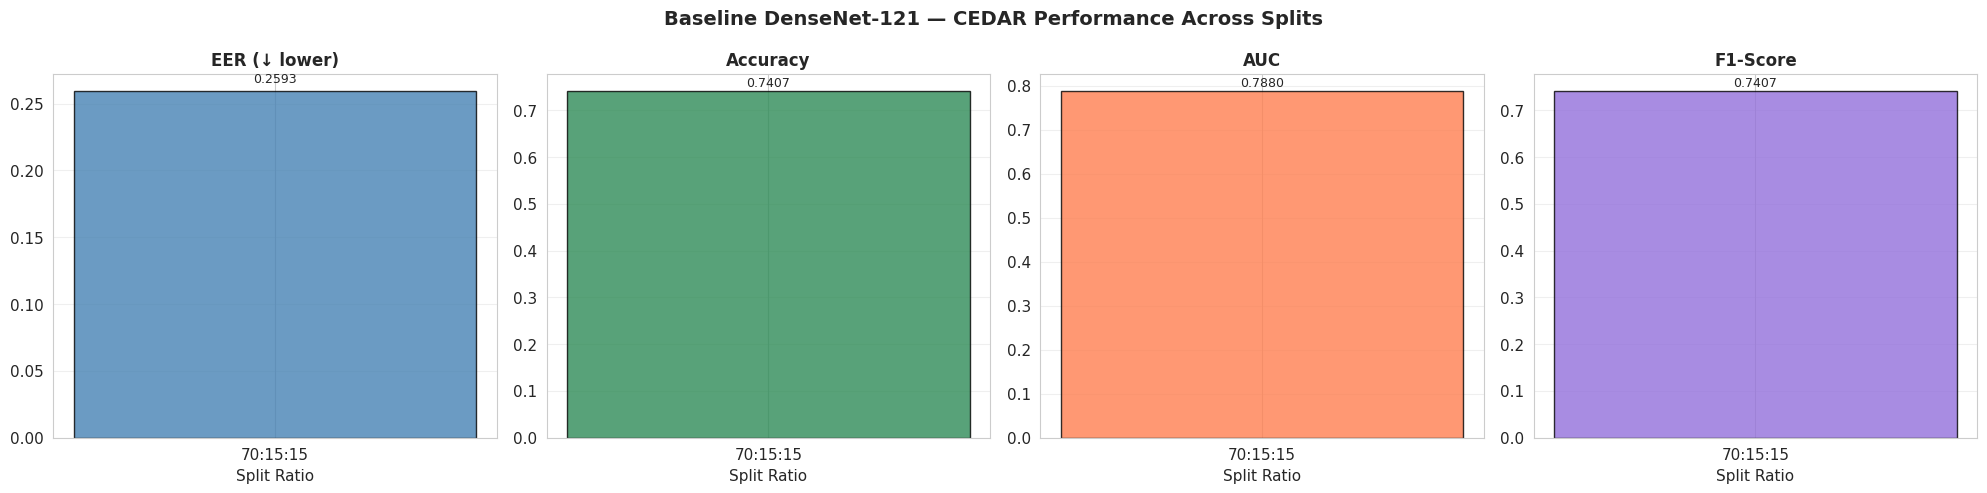

 > Plot saved → /home/lawrence/workspace/thesis/thesis/checkpoints/baseline_splits/baseline_cedar_comparison.png


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f'Baseline DenseNet-121 — {DATASET_NAME} Performance Across Splits',
             fontsize=14, fontweight='bold')

for ax, metric, title, color in zip(
        axes,
        ['eer',           'accuracy',  'auc',   'f1'],
        ['EER (↓ lower)', 'Accuracy',  'AUC',   'F1-Score'],
        ['steelblue',     'seagreen',  'coral', 'mediumpurple']):

    split_labels = [r.replace('_', ':') for r in SPLIT_RATIOS]
    values = [all_results.get(f"{DATASET_NAME} ({r.replace('_',':')})", {}).get(metric, 0)
              for r in SPLIT_RATIOS]

    bars = ax.bar(split_labels, values, color=color, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Split Ratio', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, f'baseline_{DATASET}_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" > Plot saved → {plot_path}")
